In [3]:
# Sam Remp
# IST 707 Final Project
pip install xgboost
# Load required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from sklearn.utils import resample

# Read from CSV to Pandas DataFrame
url = r"C:\Users\samre\OneDrive\Documents\Python Scripts\IST 707\Final Project\PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(url, delimiter=",")



SyntaxError: invalid syntax (Temp/ipykernel_26452/1817776058.py, line 3)

In [15]:
# Inspect the dataset
df.head(5)

NameError: name 'df' is not defined

In [13]:
df.describe()

NameError: name 'df' is not defined

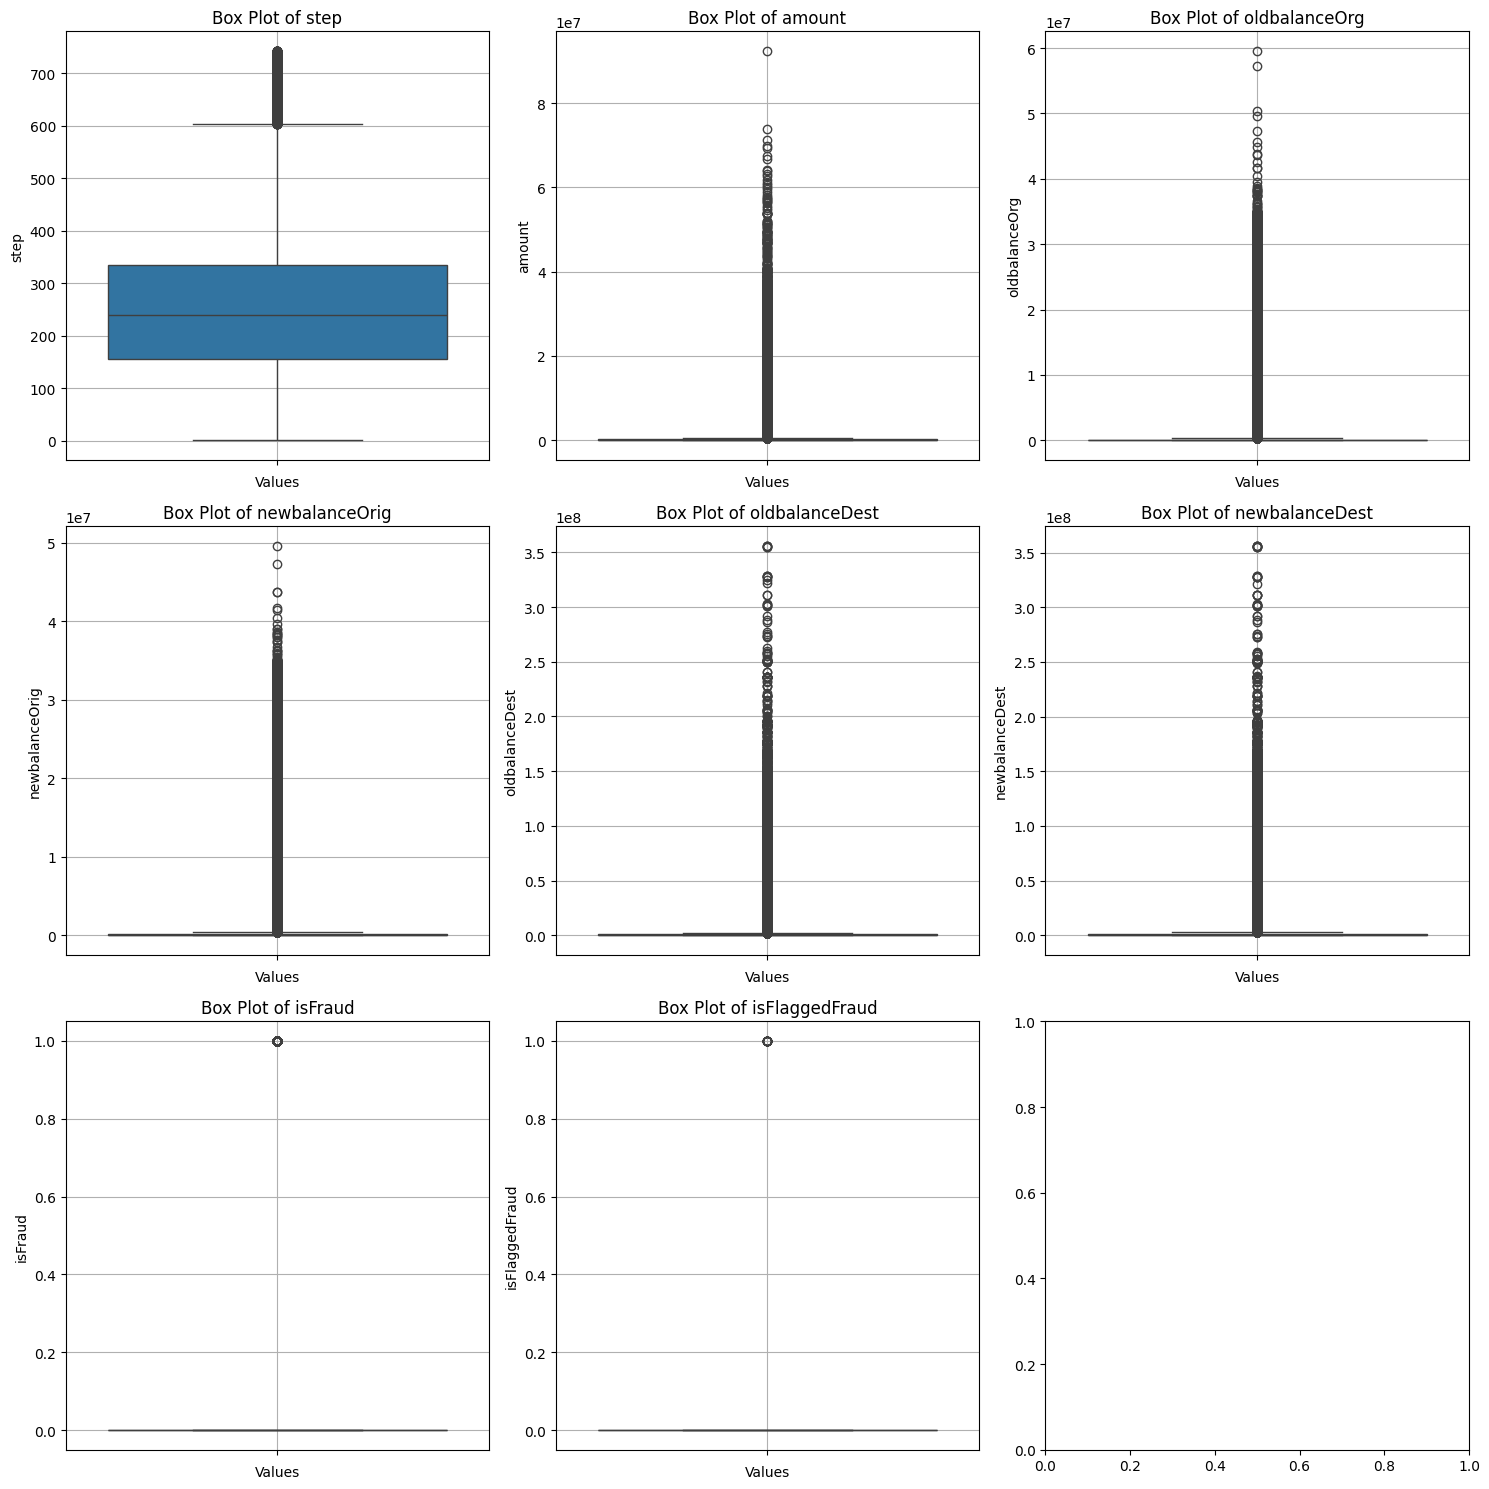

In [5]:
# Copy dataframe to make it easier to run over and over without reimporting
df_cleaned = df.copy()

# Define the numeric columns like hw2
numeric_columns = df_cleaned.select_dtypes(include='number').columns

# Set up grid layout parameters to show individual graphs. The data is drastically different y values so putting them
# in the same plot isn't feasible like last time
n_cols = 3  
n_rows = math.ceil(len(numeric_columns) / n_cols)  # Number of rows needed based on the number of numeric columns and rows

# Set up subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Plot each numeric column on its own subplot
for idx, column in enumerate(numeric_columns):
    sns.boxplot(data=df_cleaned, y=column, ax=axes[idx])
    axes[idx].set_title(f'Box Plot of {column}')
    axes[idx].set_xlabel('Values')
    axes[idx].set_ylabel(column)
    axes[idx].grid(True)

# Adjust layout to reduce space taken
plt.tight_layout()
plt.show()


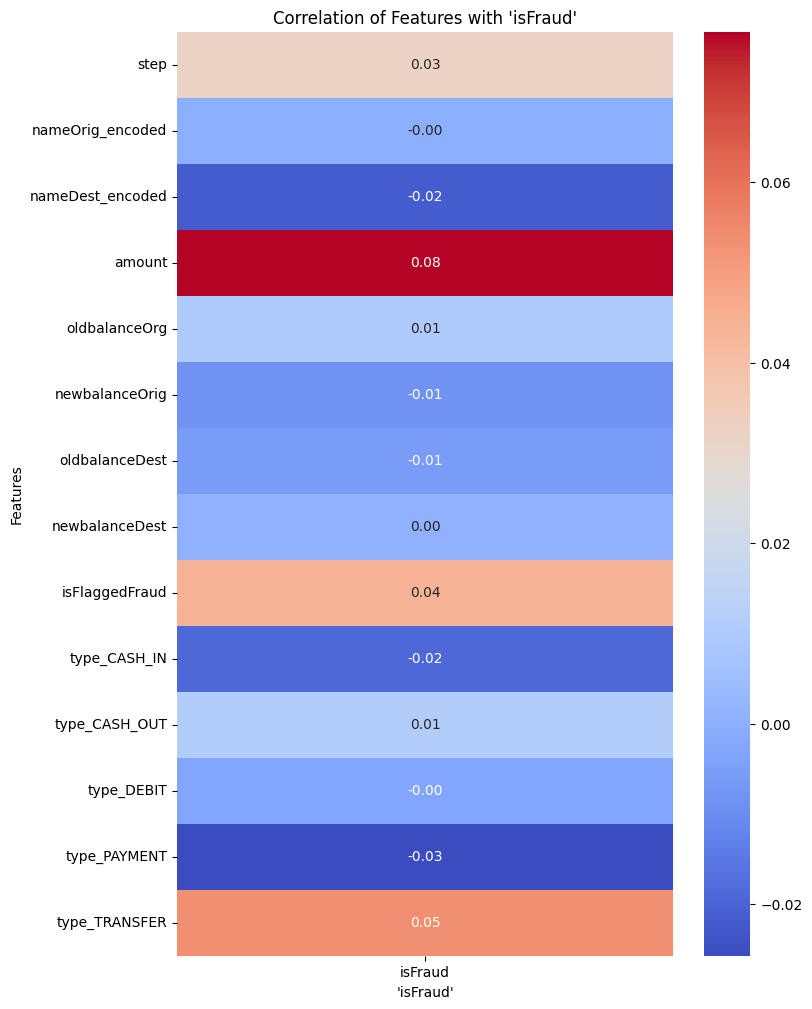

In [6]:
# Encode nameOrig and nameDest due to how many unique names in each
nameOrig_Encod = LabelEncoder()
nameDest_Encod = LabelEncoder()
df_cleaned['nameOrig_encoded'] = nameOrig_Encod.fit_transform(df_cleaned['nameOrig'])
df_cleaned['nameDest_encoded'] = nameDest_Encod.fit_transform(df_cleaned['nameDest'])

# Drop the original columns to save memory
df_cleaned.drop(columns=['nameOrig', 'nameDest'], inplace=True)

# Replace infinite values with NaN
df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), 
    StandardScaler())

# scale the data
scaler = StandardScaler()

num_attribs = ['step', 'nameOrig_encoded', 'nameDest_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 
                      'newbalanceDest', 'isFlaggedFraud', 'isFraud']
cat_attribs = ['type']


preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

# execute the transform
X_train_preprocessed = preprocessing.fit_transform(df_cleaned)
X_train_preprocessed = scaler.fit_transform(X_train_preprocessed)

# pull the names of the columns from the transform
num_col_names = num_attribs
cat_col_names = preprocessing.named_transformers_['cat'].named_steps['onehotencoder'].get_feature_names_out(cat_attribs)


# Combine numeric and categorical column names
all_cols = list(num_col_names) + list(cat_col_names)

# Create a new DataFrame with the correct column names
X_train_transformed = pd.DataFrame(X_train_preprocessed, columns=all_cols)

# calculate correlation matrix
correlation_matrix = X_train_transformed.corr()

# pull out those with a high correlation to our target variable
y_corr = correlation_matrix[['isFraud']].drop(index='isFraud')

# Plot heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(y_corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Correlation of Features with 'isFraud'")
plt.ylabel("Features")
plt.xlabel("'isFraud'")
plt.show()

In [61]:
correlation_matrix

,step,nameOrig_encoded,nameDest_encoded,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
step,1.000000,-0.000146,0.003767,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.003277,0.031578,0.004077,-0.012918,0.002869,0.004926,0.006925
nameOrig_encoded,-0.000146,1.000000,-0.000256,0.000124,-0.000648,-0.000675,0.000245,0.000255,0.000667,-0.000464,-0.000380,0.000277,0.000742,-0.000367,0.000503
nameDest_encoded,0.003767,-0.000256,1.000000,-0.169150,-0.162688,-0.166489,-0.198119,-0.203992,-0.001122,-0.021963,-0.325688,-0.451822,-0.049733,0.858153,-0.185311
amount,0.022373,0.000124,-0.169150,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.012295,0.076688,-0.009621,-0.004376,-0.023379,-0.197444,0.365896
oldbalanceOrg,-0.010058,-0.000648,-0.162688,-0.002762,1.000000,0.998803,0.066243,0.042029,0.003835,0.010154,0.506761,-0.200899,-0.021450,-0.189486,-0.081593
newbalanceOrig,-0.010299,-0.000675,-0.166489,-0.007861,0.998803,1.000000,0.067812,0.041837,0.003776,-0.008148,0.527373,-0.210977,-0.021872,-0.193915,-0.087355
oldbalanceDest,0.027665,0.000245,-0.198119,0.294137,0.066243,0.067812,1.000000,0.976569,-0.000513,-0.005885,0.076105,0.086028,0.009347,-0.231455,0.130476
newbalanceDest,0.025888,0.000255,-0.203992,0.459304,0.042029,0.041837,0.976569,1.000000,-0.000529,0.000535,0.034988,0.093476,0.006346,-0.238315,0.191701
isFlaggedFraud,0.003277,0.000667,-0.001122,0.012295,0.003835,0.003776,-0.000513,-0.000529,1.000000,0.044109,-0.000842,-0.001168,-0.000128,-0.001133,0.005245
isFraud,0.031578,-0.000464,-0.021963,0.076688,0.010154,-0.008148,-0.005885,0.000535,0.044109,1.000000,-0.019089,0.011256,-0.002911,-0.025697,0.053869


In [62]:
# Filter correlation matrix for absolute values greater than 0.1
filtered_corr_matrix = correlation_matrix[correlation_matrix.abs() > 0.025]
# Select only the correlations involving the column 'y'
filtered_corr_matrix_y = filtered_corr_matrix[['isFraud']].dropna()
filtered_corr_matrix_y

,isFraud
step,0.031578
amount,0.076688
isFlaggedFraud,0.044109
isFraud,1.000000
type_PAYMENT,-0.025697
type_TRANSFER,0.053869


In [7]:
# Based on the correlation matrix, I am going to drop low correlation values as they appear to have no real impact.
# step	amount	isFlaggedFraud	type_PAYMENT	type_TRANSFER keep
X = X_train_transformed.drop(columns=['isFraud', 'isFlaggedFraud', 'nameOrig_encoded', 'nameDest_encoded', 'oldbalanceOrg', 'newbalanceOrig',	'oldbalanceDest', 'newbalanceDest'])
y = df_cleaned['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X.head(5)

,step,amount,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,-1.703042,-0.281560,-0.530965,-0.736484,-0.08096,1.399036,-0.302345
1,-1.703042,-0.294767,-0.530965,-0.736484,-0.08096,1.399036,-0.302345
2,-1.703042,-0.297555,-0.530965,-0.736484,-0.08096,-0.714778,3.307478
3,-1.703042,-0.297555,-0.530965,1.357803,-0.08096,-0.714778,-0.302345
4,-1.703042,-0.278532,-0.530965,-0.736484,-0.08096,1.399036,-0.302345


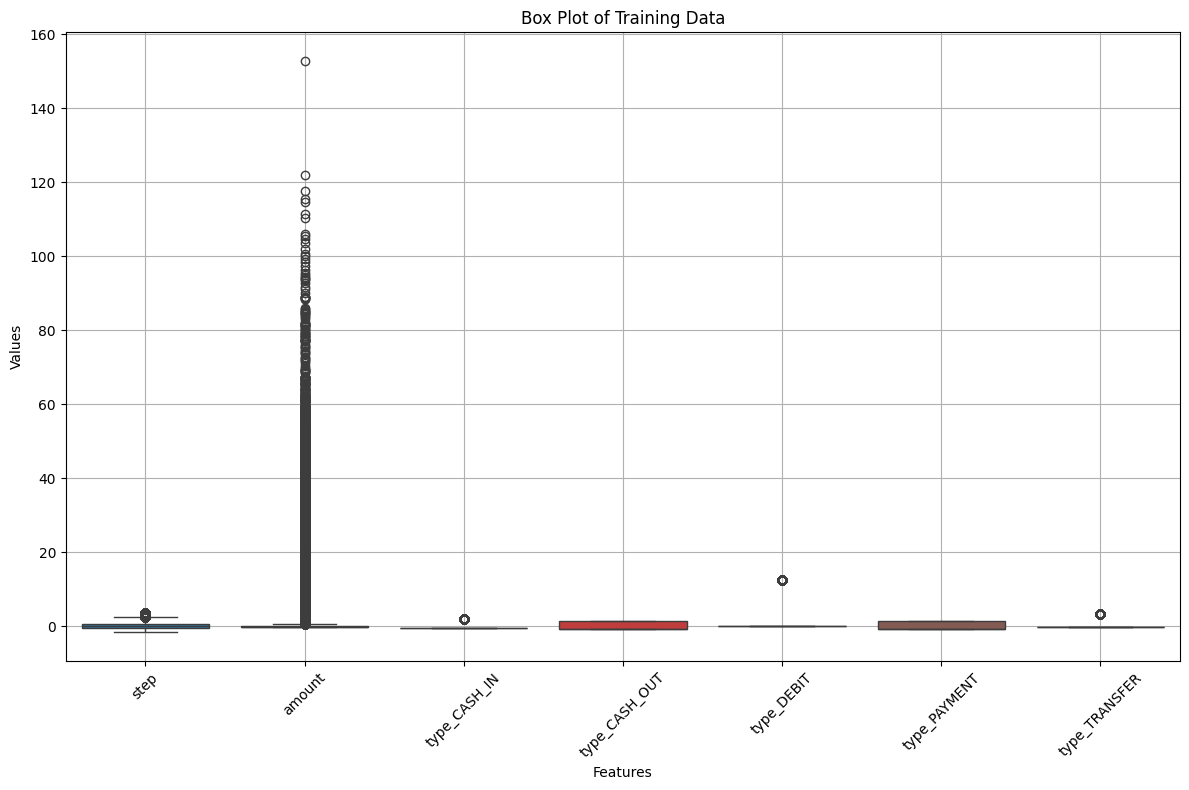

In [72]:
# inspect data now that it is cleaned and scaled
# Create a box plot for all numeric columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=X.select_dtypes(include='number'))
plt.title('Box Plot of Training Data')
plt.xticks(rotation=45)
plt.ylabel('Values')
plt.xlabel('Features')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
import warnings
from sklearn.decomposition import PCA
# Ignore convergence warnings for SVC
warnings.filterwarnings("ignore")

# Apply PCA to reduce dimensionality
def apply_pca(X, variance_threshold=0.95):
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X)
    print(f"Reduced from {X.shape[1]} to {X_pca.shape[1]} dimensions, explaining {variance_threshold*100}% of variance.")
    return X_pca

# Apply PCA for dimensionality reduction
X_pca_cleaned = apply_pca(X_train, variance_threshold=0.95)  # Adjust threshold if necessary


# Update the evaluate_model function to include F1 score and proper fitting
def evaluate_model(model, X, y, cv=3):
    if isinstance(model, SVC):
        # Evaluate SVC with different kernels
        kernels = ['rbf', 'linear']
        best_score = 0
        best_model = None
        best_kernel = None
        
        for kernel in kernels:
            svc_model = SVC(kernel=kernel, class_weight='balanced', max_iter=1000, random_state=42)
            param_grid = {
                'C': [1],
                'gamma': ['scale'],
                'tol': [1e-3], 
            }
            grid_search = GridSearchCV(svc_model, param_grid, cv=cv, scoring='accuracy')
            grid_search.fit(X, y)
            scores = cross_val_score(grid_search.best_estimator_, X, y, cv=cv, scoring='accuracy')

            if scores.mean() > best_score:
                best_score = scores.mean()
                best_model = grid_search.best_estimator_
                best_kernel = kernel

        # Calculate F1 score for the best model using cross_val_predict
        y_pred = cross_val_predict(best_model, X, y, cv=cv)
        f1 = f1_score(y, y_pred, average='weighted')  # 'weighted' average for multiclass
        return best_model, best_kernel, best_score, scores.std(), f1

    elif isinstance(model, SGDClassifier):
        # Set the 'loss' parameter for SGDClassifier to 'log' for logistic regression
        model.set_params(loss='hinge')
        
        # Evaluate model directly with transformed data using cross_val_predict
        y_pred = cross_val_predict(model, X, y, cv=cv)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        best_kernel = "NotApplicable"

        # Calculate F1 score
        f1 = f1_score(y, y_pred, average='weighted')
        return model, best_kernel, scores.mean(), scores.std(), f1

    else:
        # For other models, perform the evaluation directly
        y_pred = cross_val_predict(model, X, y, cv=cv)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        best_kernel = "NotApplicable"

        # Calculate F1 score
        f1 = f1_score(y, y_pred, average='weighted')
        return model, best_kernel, scores.mean(), scores.std(), f1

# Initialize models and evaluate
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "SGD Classifier": SGDClassifier(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_jobs=-1),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVC": SVC(),  # loop kernels
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "XGBoost": XGBClassifier()
}

results = {}
for model_name, model in models.items():
    evaluated_model, best_kernel, mean_accuracy, std_accuracy, f1 = evaluate_model(model, X_pca_cleaned, y_train)
    results[model_name] = {
        'model': evaluated_model,
        'kernel': best_kernel,
        'mean_accuracy': mean_accuracy,
        'std_accuracy': std_accuracy,
        'f1_score': f1
    }
    print(f"{model_name} Eval: Kernel: {best_kernel} Mean: {mean_accuracy:.4f}, STD: {std_accuracy:.4f}, F1 Score: {f1:.4f}")

# Identify the best model
best_model_name = max(results, key=lambda x: results[x]['mean_accuracy'])
best_model = results[best_model_name]['model']
print(f"The best model is: {best_model_name} using {results[best_model_name]['kernel']} kernel, with a mean accuracy of {results[best_model_name]['mean_accuracy']:.4f} and an F1 score of {results[best_model_name]['f1_score']:.4f}")


Reduced from 7 to 6 dimensions, explaining 95.0% of variance.
Decision Tree Eval: Kernel: NotApplicable Mean: 0.9986, STD: 0.0001, F1 Score: 0.9985
SGD Classifier Eval: Kernel: NotApplicable Mean: 0.8525, STD: 0.0121, F1 Score: 0.9191
Random Forest Eval: Kernel: NotApplicable Mean: 0.9989, STD: 0.0001, F1 Score: 0.9987
KNN Classifier Eval: Kernel: NotApplicable Mean: 0.9990, STD: 0.0000, F1 Score: 0.9987
SVC Eval: Kernel: linear Mean: 0.1159, STD: 0.1592, F1 Score: 0.2058
Logistic Regression Eval: Kernel: NotApplicable Mean: 0.7855, STD: 0.0032, F1 Score: 0.8786
XGBoost Eval: Kernel: NotApplicable Mean: 0.9990, STD: 0.0000, F1 Score: 0.9987
The best model is: XGBoost using NotApplicable kernel, with a mean accuracy of 0.9990 and an F1 score of 0.9987


In [33]:
from sklearn.metrics import accuracy_score
best_model.fit(X_train, y_train)

# Predict on the transformed test set
y_pred = best_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9989


In [85]:
Test_df = pd.DataFrame(X_test)
y_test_series = pd.Series(y_test, name='isFraud')  # Name the column 'Actual'
y_pred_series = pd.Series(y_pred, name='isFraudPred')  # Name the column 'Predicted'
Test_df.reset_index(inplace=True)
y_test_series=y_test_series.reset_index()
Test_df['isFraud'] = y_test_series['isFraud']
Test_df['isFraudPred'] = y_pred_series
Test_df=Test_df.drop(columns=['index'])
Test_df.to_csv('PredictedFraud.csv', index=False)

In [89]:
X_df=pd.DataFrame(X)
y_df = pd.DataFrame(y)
X_df['isFraud'] = y_df
X_df.to_csv('CleanedDataRaw.csv', index=False)